# 01 · Data ETL

## 0 · Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent   
sys.path.append(str(ROOT))

In [2]:
import sys, logging
from pathlib import Path
import pandas as pd

from src.data import fetch_ticker, fetch_macro, get_trading_days, align_panel, quality_check, filter_valid, build_dataset
from src.utils.io                 import save, load
from src.config             import load_config

from src.data import fetch_benchmark

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)-8s | %(name)s | %(message)s'
)



cfg = load_config(ROOT / 'configs' / 'base.yaml')

# TEST_MODE = True  → 5 ticker, kiểm tra nhanh
# TEST_MODE = False → full universe
TEST_MODE = False
tickers = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'TSLA'] if TEST_MODE else cfg.data.tickers

print(f'ROOT      : {ROOT}')
print(f'Giai đoạn : {cfg.data.start_date} → {cfg.data.end_date}')
print(f'Tickers   : {len(tickers)} ({"TEST" if TEST_MODE else "FULL"})')

ROOT      : C:\Users\H13P\Desktop\DOAN - Copy\project_v7_final - Copy\project_v7_final
Giai đoạn : 2014-01-01 → 2026-03-01
Tickers   : 36 (FULL)


## 1 · Fetch stocks từ Tiingo
Kết quả cache vào `data/raw/cache/` → chạy lại không tốn API call.

In [3]:
frames, skipped = [], []

for i, tkr in enumerate(tickers, 1):
    print(f'[{i:02d}/{len(tickers)}] {tkr} ...', end=' ')
    try:
        df = fetch_ticker(
            tkr,
            cfg.data.start_date,
            cfg.data.end_date,
            cache_dir=cfg.dir_cache,
        )
        df['ticker'] = tkr
        frames.append(df.reset_index().set_index(['date', 'ticker']))
        print(f'{len(df)} ngày')
    except Exception as e:
        print(f'LỖI: {e}')
        skipped.append(tkr)

stocks_raw = pd.concat(frames).sort_index()
print(f'\nstocks_raw : {stocks_raw.shape}')
print(f'skipped    : {skipped if skipped else "không có"}')
stocks_raw.head(6)

[01/36] AAPL ... 

INFO     | src.data.tiingo_client | [AAPL] OK — 3057 ngày (2014-01-02 → 2026-02-27)


3057 ngày
[02/36] MSFT ... 

INFO     | src.data.tiingo_client | [MSFT] OK — 3057 ngày (2014-01-02 → 2026-02-27)


3057 ngày
[03/36] NVDA ... 

...

INFO     | src.data.tiingo_client | [FAST] OK — 3057 ngày (2014-01-02 → 2026-02-27)


3057 ngày
[36/36] ODFL ... 

INFO     | src.data.tiingo_client | [ODFL] OK — 3057 ngày (2014-01-02 → 2026-02-27)


3057 ngày

stocks_raw : (109664, 5)
skipped    : không có


adj_open   adj_high    adj_low  adj_close  adj_volume
date       ticker                                                        
2014-01-02 AAPL    17.220485  17.262322  17.107093  17.141461   234685034
           ADBE    59.060000  59.530000  58.940000  59.290000     2745900
           AMAT    15.115686  15.115686  14.842253  14.996059     7785900
           AMD      3.850000   3.980000   3.840000   3.950000    20548400
           AMGN    81.181442  82.480516  80.968479  82.200115     2528800
           AMZN    19.940000  19.968000  19.701000  19.898500    42756000

## 2 · Fetch VIX & VXN từ Yahoo Finance

In [4]:
macro_raw = fetch_macro(cfg.data.start_date, cfg.data.end_date)

print(f'macro_raw : {macro_raw.shape}')
print(f'VIX range : {macro_raw["vix"].min():.1f} – {macro_raw["vix"].max():.1f}')
print(f'VXN range : {macro_raw["vxn"].min():.1f} – {macro_raw["vxn"].max():.1f}')
macro_raw.head()

INFO     | src.data.fetch_macro | Fetching ^VIX ...
INFO     | src.data.fetch_macro | Fetching ^VXN ...
INFO     | src.data.fetch_macro | fetch_macro OK: 3057 ngày | VIX [9.1–82.7] VXN [10.3–80.1]


macro_raw : (3057, 2)
VIX range : 9.1 – 82.7
VXN range : 10.3 – 80.1


,vix,vxn
date,,
2014-01-02,14.23,15.88
2014-01-03,13.76,15.85
2014-01-06,13.55,15.82
2014-01-07,12.92,15.10
2014-01-08,12.87,14.88


## 3 · Kiểm tra dữ liệu thô
Xem xét dữ liệu **trước khi clean** để quyết định loại ticker nào.

Tiêu chí loại:
- Số ngày giao dịch < `min_trading_days`
- NaN trong `adj_close` > `max_nan_ratio`
- Có giá `adj_close <= 0`

In [5]:
# 3.1 Ngày bắt đầu / kết thúc từng ticker
summary = []
for tkr, grp in stocks_raw.groupby(level='ticker'):
    dates = grp.index.get_level_values('date')
    col   = grp['adj_close']
    summary.append({
        'ticker':    tkr,
        'start':     dates.min().date(),
        'end':       dates.max().date(),
        'n_days':    len(grp),
        'nan_pct':   round(col.isna().mean() * 100, 2),
        'bad_price': (col.dropna() <= 0).any(),
    })

summary_df = pd.DataFrame(summary).sort_values('n_days')
print(f'Tổng: {len(summary_df)} tickers')
summary_df

Tổng: 36 tickers


,ticker,start,end,n_days,nan_pct,bad_price
29,PYPL,2015-07-20,2026-02-27,2669,0.0,False
0,AAPL,2014-01-02,2026-02-27,3057,0.0,False
20,MSFT,2014-01-02,2026-02-27,3057,0.0,False
21,MU,2014-01-02,2026-02-27,3057,0.0,False
22,NFLX,2014-01-02,2026-02-27,3057,0.0,False
23,NVDA,2014-01-02,2026-02-27,3057,0.0,False
24,ODFL,2014-01-02,2026-02-27,3057,0.0,False
25,ORCL,2014-01-02,2026-02-27,3057,0.0,False
26,PANW,2014-01-02,2026-02-27,3057,0.0,False
27,PAYX,2014-01-02,2026-02-27,3057,0.0,False


In [6]:
# 3.2 Ngày đầu tiên trong raw — kiểm tra có ngày lễ lọt vào không
first_dates = stocks_raw.index.get_level_values('date').unique().sort_values()[:10]
print('10 ngày đầu trong raw data:')
for d in first_dates:
    print(f'  {d.date()}')

10 ngày đầu trong raw data:
  2014-01-02
  2014-01-03
  2014-01-06
  2014-01-07
  2014-01-08
  2014-01-09
  2014-01-10
  2014-01-13
  2014-01-14
  2014-01-15


In [7]:
# 3.3 NaN% toàn bộ
nan_pct = stocks_raw.isna().mean().sort_values(ascending=False)
has_nan = nan_pct[nan_pct > 0]
if has_nan.empty:
    print('✓ Không có NaN trong raw data')
else:
    print('Cột có NaN:')
    print(has_nan.apply(lambda x: f'{x:.2%}'))

✓ Không có NaN trong raw data


In [8]:
# 3.4 QC report — chạy trên raw để xem ticker nào có vấn đề
qc_report, valid_tickers = quality_check(
    stocks_raw,
    min_days      = cfg.data.min_trading_days,
    max_nan_ratio = cfg.data.max_nan_ratio,
)

bad = qc_report[~qc_report['valid']]
print(f'Tổng: {len(qc_report)} | Hợp lệ: {len(valid_tickers)} | Loại: {len(bad)}')
if not bad.empty:
    print('\nTicker bị loại:')
    display(bad)
qc_report

INFO     | src.data.clean | quality_check: 36/36 ticker hợp lệ


Tổng: 36 | Hợp lệ: 36 | Loại: 0


,ticker,n_total,n_valid,nan_pct_close,nan_pct_max_col,max_consec,bad_price,has_dup,valid
0,AAPL,3057,3057,0.0,0.0,0,False,False,True
1,ADBE,3057,3057,0.0,0.0,0,False,False,True
20,MSFT,3057,3057,0.0,0.0,0,False,False,True
21,MU,3057,3057,0.0,0.0,0,False,False,True
22,NFLX,3057,3057,0.0,0.0,0,False,False,True
23,NVDA,3057,3057,0.0,0.0,0,False,False,True
24,ODFL,3057,3057,0.0,0.0,0,False,False,True
25,ORCL,3057,3057,0.0,0.0,0,False,False,True
26,PANW,3057,3057,0.0,0.0,0,False,False,True
27,PAYX,3057,3057,0.0,0.0,0,False,False,True


## 4 · Clean
- Loại ticker không đạt QC
- Loại ngày không phải trading day NYSE (ngày lễ, cuối tuần...)
- `ffill(limit=1)` để fill qua ngày lễ đơn lẻ nếu cần

In [9]:
# 4.1 Loại ticker kém
stocks_clean = filter_valid(stocks_raw, valid_tickers)
print(f'Sau khi loại ticker kém: {stocks_clean.shape}')

Sau khi loại ticker kém: (109664, 5)


In [10]:
# 4.2 Lấy danh sách ngày giao dịch NYSE
trading_days = get_trading_days(cfg.data.start_date, cfg.data.end_date)

print(f'NYSE trading days: {len(trading_days)}')
print(f'Từ {trading_days[0].date()} → {trading_days[-1].date()}')
print(f'\n5 ngày đầu:')
for d in trading_days[:5]:
    print(f'  {d.date()}')

INFO     | src.data.clean | NYSE calendar: 3057 ngày (2014-01-02 → 2026-02-27)


NYSE trading days: 3057
Từ 2014-01-02 → 2026-02-27

5 ngày đầu:
  2014-01-02
  2014-01-03
  2014-01-06
  2014-01-07
  2014-01-08


In [11]:
# 4.3 Fetch benchmark QQQ + Align về NYSE calendar
bench_raw = fetch_benchmark(
    ticker=cfg.data.benchmark_ticker,
    start=cfg.data.start_date,
    end=cfg.data.end_date,
    cache_dir=cfg.dir_cache / 'benchmark',
)
print(f'QQQ: {len(bench_raw)} ngày')

stocks_al, macro_al, bench_al = align_panel(
    stocks_clean, macro_raw,
    cfg.data.start_date,
    cfg.data.end_date,
    bench=bench_raw,
)

first_dates_clean = stocks_al.index.get_level_values('date').unique().sort_values()[:5]
print('5 ngày đầu sau clean:')
for d in first_dates_clean:
    print(f'  {d.date()}')

print(f'\nstocks_al : {stocks_al.shape}')
print(f'macro_al  : {macro_al.shape}')
print(f'bench_al  : {len(bench_al)} ngày')


INFO     | src.data.fetch_benchmark | Fetching benchmark QQQ ...
INFO     | src.data.fetch_benchmark | fetch_benchmark: cached → bench_QQQ_2014-01-01_2026-03-01.parquet
INFO     | src.data.fetch_benchmark | fetch_benchmark OK: 3057 ngày (2014-01-02 → 2026-02-27)


QQQ: 3057 ngày


INFO     | src.data.clean | NYSE calendar: 3057 ngày (2014-01-02 → 2026-02-27)
INFO     | src.data.clean | stocks_al : (110052, 5) | 2014-01-02 → 2026-02-27
INFO     | src.data.clean | macro_al  : (3057, 2)
INFO     | src.data.clean | bench_al  : 3057 ngày


5 ngày đầu sau clean:
  2014-01-02
  2014-01-03
  2014-01-06
  2014-01-07
  2014-01-08

stocks_al : (110052, 5)
macro_al  : (3057, 2)
bench_al  : 3057 ngày


In [12]:
# 4.4 Kiểm tra NaN sau align
nan_after = stocks_al.isna().mean().sort_values(ascending=False)
has_nan   = nan_after[nan_after > 0]
if has_nan.empty:
    print('✓ Không có NaN sau align')
else:
    print('Cột còn NaN sau align:')
    print(has_nan.apply(lambda x: f'{x:.2%}'))

Cột còn NaN sau align:
adj_open      0.35%
adj_high      0.35%
adj_low       0.35%
adj_close     0.35%
adj_volume    0.35%
dtype: object


## 5 · Merge stocks + macro
Left join theo `date` — VIX/VXN ngày `t` broadcast cho tất cả ticker.  
Không look-ahead bias vì macro ngày `t` là thông tin đã biết khi giao dịch.

In [13]:
merged = build_dataset(stocks_al, macro_al, bench=bench_al)

# Sanity checks
assert merged.index.names == ['date', 'ticker'],  'MultiIndex sai!'
assert not merged.index.duplicated().any(),        'Có duplicate index!'
assert 'vix' in merged.columns,                   'Thiếu cột vix!'
assert 'vxn' in merged.columns,                   'Thiếu cột vxn!'
assert len(merged) == len(stocks_al),              'Mất hàng sau merge!'
assert merged['vix'].isna().sum() == 0,            'Còn NaN ở vix!'
assert merged['vxn'].isna().sum() == 0,            'Còn NaN ở vxn!'
assert 'bench_close' in merged.columns,           'Thiếu cột bench_close!'

dates = merged.index.get_level_values('date')
print(f'merged     : {merged.shape}')
print(f'date range : {dates.min().date()} → {dates.max().date()}')
print(f'tickers    : {merged.index.get_level_values("ticker").nunique()}')
print(f'columns    : {list(merged.columns)}')
print('✓ Tất cả assertions passed')
merged.head(6)

INFO     | src.data.build_dataset | build_dataset: 110,052 rows | columns=['adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume', 'vix', 'vxn', 'bench_close']


merged     : (110052, 8)
date range : 2014-01-02 → 2026-02-27
tickers    : 36
columns    : ['adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume', 'vix', 'vxn', 'bench_close']
✓ Tất cả assertions passed


adj_open   adj_high    adj_low  adj_close   adj_volume  \
date       ticker                                                            
2014-01-02 AAPL    17.220485  17.262322  17.107093  17.141461  234685034.0   
           ADBE    59.060000  59.530000  58.940000  59.290000    2745900.0   
           AMAT    15.115686  15.115686  14.842253  14.996059    7785900.0   
           AMD      3.850000   3.980000   3.840000   3.950000   20548400.0   
           AMGN    81.181442  82.480516  80.968479  82.200115    2528800.0   
           AMZN    19.940000  19.968000  19.701000  19.898500   42756000.0   

                     vix    vxn  bench_close  
date       ticker                             
2014-01-02 AAPL    14.23  15.88    79.143295  
           ADBE    14.23  15.88    79.143295  
           AMAT    14.23  15.88    79.143295  
           AMD     14.23  15.88    79.143295  
           AMGN    14.23  15.88    79.143295  
           AMZN    14.23  15.88    79.143295

## 6 · Visualize

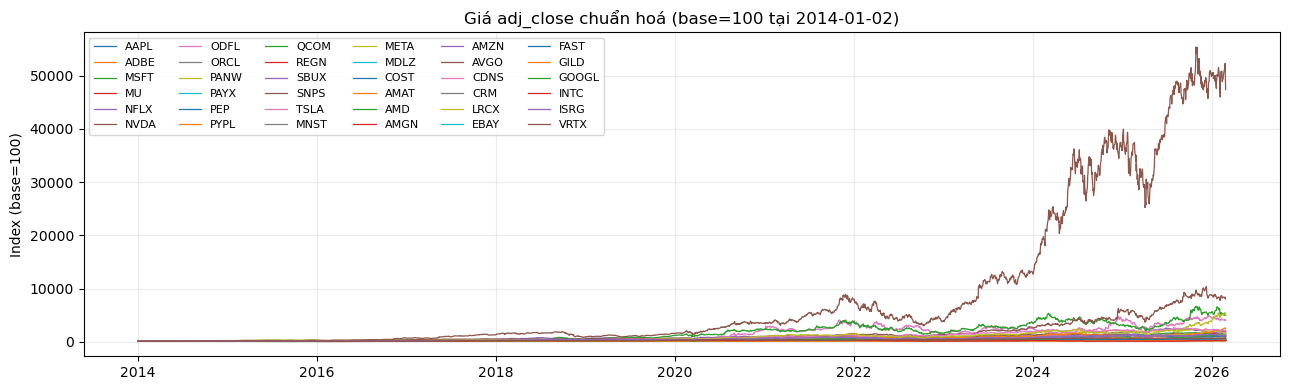

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13, 4))
for tkr in valid_tickers:
    try:
        s = merged.xs(tkr, level='ticker')['adj_close'].dropna()
        ax.plot(s.index, s / s.iloc[0] * 100, lw=0.9, label=tkr)
    except KeyError:
        pass
ax.set_title('Giá adj_close chuẩn hoá (base=100 tại 2014-01-02)', fontsize=12)
ax.set_ylabel('Index (base=100)')
ax.legend(fontsize=8, ncol=6)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(alpha=0.25)
plt.tight_layout()
out_fig = ROOT / 'outputs' / 'figures'
out_fig.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig / '01a_adj_close.png', dpi=130, bbox_inches='tight')
plt.show()

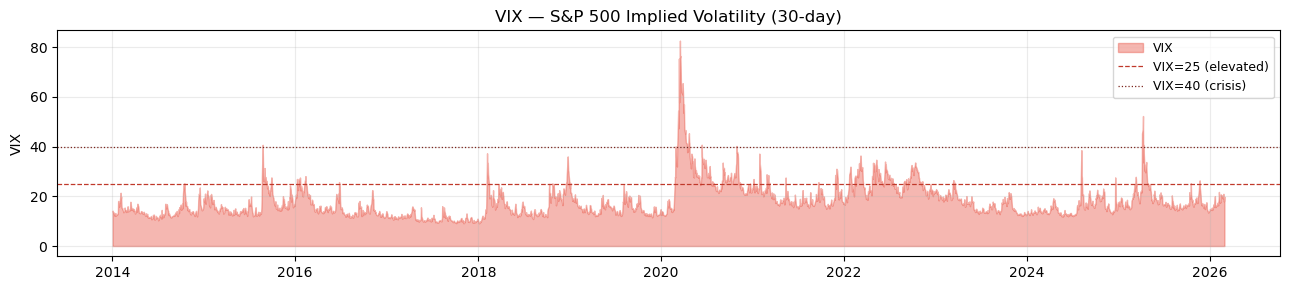

In [15]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.fill_between(macro_al.index, macro_al['vix'], alpha=0.4, color='#e74c3c', label='VIX')
ax.axhline(25, color='#c0392b', ls='--', lw=0.9, label='VIX=25 (elevated)')
ax.axhline(40, color='#7b241c', ls=':',  lw=0.9, label='VIX=40 (crisis)')
ax.set_title('VIX — S&P 500 Implied Volatility (30-day)', fontsize=12)
ax.set_ylabel('VIX')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(out_fig / '01b_vix.png', dpi=130, bbox_inches='tight')
plt.show()

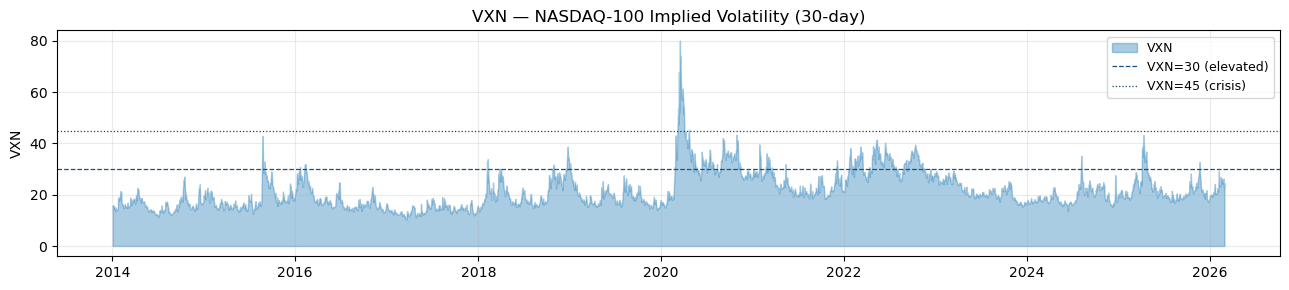

In [16]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.fill_between(macro_al.index, macro_al['vxn'], alpha=0.4, color='#2980b9', label='VXN')
ax.axhline(30, color='#1a5276', ls='--', lw=0.9, label='VXN=30 (elevated)')
ax.axhline(45, color='#154360', ls=':',  lw=0.9, label='VXN=45 (crisis)')
ax.set_title('VXN — NASDAQ-100 Implied Volatility (30-day)', fontsize=12)
ax.set_ylabel('VXN')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(out_fig / '01c_vxn.png', dpi=130, bbox_inches='tight')
plt.show()

## 7 · Lưu Parquet
- `data/raw/` — dữ liệu gốc từ API, không chỉnh sửa
- `data/interim/` — đã clean & merge, dùng cho bước tiếp theo

In [17]:
save(stocks_raw, cfg.dir_raw     / 'stocks_daily.parquet')
save(macro_raw,  cfg.dir_raw     / 'macro_vix_vxn.parquet')
save(bench_raw.to_frame('bench_close'), cfg.dir_raw / 'benchmark_qqq.parquet')
save(merged,     cfg.dir_interim / 'dataset_merged.parquet')
for p in [
    cfg.dir_raw     / 'stocks_daily.parquet',
    cfg.dir_raw     / 'macro_vix_vxn.parquet',
    cfg.dir_raw     / 'benchmark_qqq.parquet',
    cfg.dir_interim / 'dataset_merged.parquet',
]:
    size_kb = Path(p).stat().st_size / 1024
    print(f'{p.name:<40} {size_kb:>8.1f} KB')

stocks_daily.parquet                       4777.5 KB
macro_vix_vxn.parquet                        55.4 KB
benchmark_qqq.parquet                        50.2 KB
dataset_merged.parquet                     4877.9 KB


## 8 · Verify — load lại kiểm tra
Đảm bảo Parquet round-trip không mất MultiIndex hay thay đổi dtype.

In [18]:
reloaded = load(cfg.dir_interim / 'dataset_merged.parquet')

assert reloaded.index.names == ['date', 'ticker'], 'MultiIndex mất sau load!'
assert len(reloaded) == len(merged),               'Số hàng thay đổi!'
assert pd.api.types.is_datetime64_any_dtype(
    reloaded.index.get_level_values('date')),      'date không phải datetime!'

# Kiểm tra không còn ngày lễ
first_date = reloaded.index.get_level_values('date').min()
assert first_date.month != 1 or first_date.day != 1, \
    f'Vẫn còn ngày 1/1 trong dataset: {first_date}'

print('✓ MultiIndex OK')
print('✓ Số hàng OK')
print('✓ dtype datetime OK')
print('✓ Không có ngày lễ 1/1 OK')
print(f'\ndate range : {reloaded.index.get_level_values("date").min().date()}'
      f' → {reloaded.index.get_level_values("date").max().date()}')
print(f'Ready → 02_features.ipynb')
reloaded.tail(4)

✓ MultiIndex OK
✓ Số hàng OK
✓ dtype datetime OK
✓ Không có ngày lễ 1/1 OK

date range : 2014-01-02 → 2026-02-27
Ready → 02_features.ipynb


adj_open  adj_high  adj_low  adj_close  adj_volume  \
date       ticker                                                       
2026-02-27 SBUX       96.40    98.425    96.11      98.02   7286909.0   
           SNPS      410.41   417.150   404.53     414.00   4647635.0   
           TSLA      402.94   407.120   398.11     402.51  56890097.0   
           VRTX      480.31   497.800   479.75     496.83   1782950.0   

                         vix    vxn  bench_close  
date       ticker                                 
2026-02-27 SBUX    19.860001  24.52   607.289978  
           SNPS    19.860001  24.52   607.289978  
           TSLA    19.860001  24.52   607.289978  
           VRTX    19.860001  24.52   607.289978